# Q17–Q22 — Factor Model, VaR, ES and Portfolio Risk Decomposition
**SMM269 Fixed Income | UniCredit IT0005599110**

| Question | Topic |
|---|---|
| **Q17** | Factor model: beta coefficients from historical data |
| **Q18** | Monte Carlo VaR and ES (99%, 1-day horizon) |
| **Q19** | Exact analytical VaR and ES; comparison with Monte Carlo |
| **Q20** | Bond VaR decomposition by factor |
| **Q21** | Portfolio VaR decomposition (bond + IRS 1Y/5Y/10Y hedges) |
| **Q22** | Summary table: fair values and risk sensitivities |

**Prerequisites:** `Q11_PCA.ipynb` → `Q12_Q13_Q14_Sensitivity_Hedging.ipynb` → `Q15_CreditDV01.ipynb`

---
## Imports

In [53]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os, sys

np.random.seed(42)

_here = os.path.dirname(os.path.abspath(__file__)) if "__file__" in dir() else os.getcwd()
sys.path.insert(0, _here)

from scipy.stats import norm

print("Q17-Q22 imports OK")


Q17-Q22 imports OK


---
## Load PCA outputs from Q11

In [54]:
ev_path = os.path.join(_here, "pca_eigenvalues.csv")
sc_path = os.path.join(_here, "pca_scores.csv")

for p in [ev_path, sc_path]:
    if not os.path.isfile(p):
        raise FileNotFoundError(
            f"Cannot find {os.path.basename(p)}.\n"
            "Run Q11_PCA.ipynb first."
        )

ev_df       = pd.read_csv(ev_path, index_col=0)
scores_df   = pd.read_csv(sc_path, index_col=0, parse_dates=True)

eigenvalues     = ev_df["eigenvalue_bp2"].values   # (8,) in bp^2
lam3            = eigenvalues[:3]                    # first 3 PCs
factor_scores_3 = scores_df[["PC1", "PC2", "PC3"]].values

print(f"PCA outputs loaded:")
print(f"  Eigenvalues (3 PCs): {lam3.round(3)}")
print(f"  Factor scores: {factor_scores_3.shape}  (days x 3 factors, in bp)")


PCA outputs loaded:
  Eigenvalues (3 PCs): [94.719 10.461  1.757]
  Factor scores: (2576, 3)  (days x 3 factors, in bp)


---
## Model inputs

`beta_bond` and `beta_cds` are derived from the bond DV01 vector (Q12) and the credit DV01 (Q15) respectively. `hedge_beta_matrix` encodes the factor sensitivity of each IRS hedge position.

In [55]:
# =============================================================================
# Q17 — Factor model parameters
# =============================================================================

# Bond factor betas: b = EIGVEC_HEDGE.T @ bond_dv01_vec  (from Q12)
beta_bond = np.array([
    +0.0531,   # PC1 Level
    -0.0520,   # PC2 Slope
    -0.0609,   # PC3 Curvature
])  # EUR per bp of factor, per EUR 1000 nominal

# Credit DV01 and risky gross price (from Q15)
beta_cds         = -0.7352    # EUR per bp CDS widening, per EUR 1000 nominal
bond_gross_price = 1072.9823  # EUR per EUR 1000 nominal

# Hedge factor betas: hedge_beta_matrix[i,k] = notionals[i] * A[i,k]
# Instruments: IRS 1Y, IRS 5Y, IRS 10Y (annual fixed leg, EUR).
# Column sums equal -beta_bond: the hedge eliminates all three IR factor exposures.
hedge_beta_matrix = np.array([
    [-0.00446083,  0.00929275, -0.01728409],   # IRS 1Y
    [-0.06933695,  0.03054295,  0.08104683],   # IRS 5Y
    [ 0.02072826,  0.01216051, -0.00289895],   # IRS 10Y
])  # EUR per bp of factor, per EUR 1000 bond

# Historical UniCredit 5Y EUR CDS daily variance (UNIC5YEUAM=R)
_cds_file = os.path.join(_here, 'Unicredit5Y_CDS_Data.csv')
if os.path.isfile(_cds_file):
    _cds_raw = pd.read_csv(_cds_file)
    _cds_raw['Date'] = pd.to_datetime(_cds_raw['Date'], format='%m/%d/%Y')
    _cds_raw = _cds_raw.set_index('Date').sort_index()
    cds_changes_s = _cds_raw['Price'].diff().dropna()
    cds_var = float(cds_changes_s.var())
    print(f'CDS data loaded: {len(_cds_raw)} days, '
          f'variance = {cds_var:.4f} bp^2, '
          f'daily sigma = {cds_changes_s.std():.4f} bp')
else:
    cds_var = 21.8164   # bp^2
    print(f'CDS file not found. Using pre-computed variance = {cds_var:.4f} bp^2')

N_SIM  = 1_000_000
ALPHA  = 0.01   # 99% confidence level

FACTOR_NAMES_IR = ['PC1 Level', 'PC2 Slope', 'PC3 Curvature']
FACTOR_NAMES    = FACTOR_NAMES_IR + ['CDS Spread']

betas_all = np.append(beta_bond, beta_cds)   # (4,)
variances = np.array([lam3[0], lam3[1], lam3[2], cds_var])  # bp^2

print()
print(f'Factor model: {len(betas_all)} factors')
print(f"  {'Factor':<22s}  {'beta (EUR/bp)':>14s}  {'sigma (bp/day)':>14s}")
print('  ' + '-'*52)
for name, b, var in zip(FACTOR_NAMES, betas_all, variances):
    print(f'  {name:<22s}  {b:>+14.4f}  {np.sqrt(var):>14.4f}')
print()
print('Hedge check: column sums of hedge_beta_matrix should equal -beta_bond:')
sums = hedge_beta_matrix.sum(axis=0)
for name, s, bk in zip(FACTOR_NAMES_IR, sums, beta_bond):
    print(f'  {name:<22s}  sum={s:+.6f}  target={-bk:+.6f}  diff={s+bk:+.2e}')


CDS data loaded: 2564 days, variance = 21.8164 bp^2, daily sigma = 4.6708 bp

Factor model: 4 factors
  Factor                   beta (EUR/bp)  sigma (bp/day)
  ----------------------------------------------------
  PC1 Level                      +0.0531          9.7324
  PC2 Slope                      -0.0520          3.2344
  PC3 Curvature                  -0.0609          1.3257
  CDS Spread                     -0.7352          4.6708

Hedge check: column sums of hedge_beta_matrix should equal -beta_bond:
  PC1 Level               sum=-0.053070  target=-0.053100  diff=+3.05e-05
  PC2 Slope               sum=+0.051996  target=+0.052000  diff=-3.79e-06
  PC3 Curvature           sum=+0.060864  target=+0.060900  diff=-3.62e-05


---
## Q17: Factor model -- OLS betas vs analytical betas

In [56]:
# Implied P&L from the linear model
bond_pnl_implied = factor_scores_3 @ beta_bond

from numpy.linalg import lstsq
betas_ols, _, _, _ = lstsq(factor_scores_3, bond_pnl_implied, rcond=None)

print("Q17 -- Factor model (IR factors, OLS):")
print(f"  {'Factor':<20s}  {'Analytical':>12s}  {'OLS estimate':>13s}")
print("  " + "-"*48)
for k, name in enumerate(FACTOR_NAMES_IR):
    print(f"  {name:<20s}  {beta_bond[k]:>+12.4f}  {betas_ols[k]:>+13.4f}")
print()
print(f"CDS beta (from Q15): {beta_cds:.4f} EUR/bp")
print()
print("Historical factor score statistics (from Q11):")
display(pd.DataFrame({
    "Mean (bp)": factor_scores_3.mean(axis=0).round(4),
    "Std Dev (bp)": factor_scores_3.std(axis=0).round(4),
    "Skew": pd.DataFrame(factor_scores_3).skew().round(3).values,
    "Kurt": pd.DataFrame(factor_scores_3).kurt().round(3).values,
}, index=FACTOR_NAMES_IR))


Q17 -- Factor model (IR factors, OLS):
  Factor                  Analytical   OLS estimate
  ------------------------------------------------
  PC1 Level                  +0.0531        +0.0531
  PC2 Slope                  -0.0520        -0.0520
  PC3 Curvature              -0.0609        -0.0609

CDS beta (from Q15): -0.7352 EUR/bp

Historical factor score statistics (from Q11):


,Mean (bp),Std Dev (bp),Skew,Kurt
PC1 Level,0.0,9.7305,-0.120,4.064
PC2 Slope,0.0,3.2338,0.104,4.490
PC3 Curvature,0.0,1.3254,-1.411,36.735


---
## Q18: Monte Carlo VaR and ES

In [57]:
sim_factors = np.column_stack([
    np.random.normal(0, np.sqrt(variances[k]), N_SIM)
    for k in range(4)
])  # (N_SIM, 4)

sim_pnl = sim_factors @ betas_all

cutoff = np.percentile(sim_pnl, ALPHA * 100)
VaR_MC = -cutoff
ES_MC  = -sim_pnl[sim_pnl <= cutoff].mean()

print("Q18 -- MONTE CARLO RESULTS")
print(f"  Simulations:       {N_SIM:,}")
print(f"  P&L std dev:       {sim_pnl.std():.4f} EUR")
print(f"  P&L range:         [{sim_pnl.min():+.2f}, {sim_pnl.max():+.2f}] EUR")
print()
print(f"  VaR(99%) [MC]:     EUR {VaR_MC:.4f}")
print(f"  ES(99%)  [MC]:     EUR {ES_MC:.4f}")
print(f"  VaR as % of price: {VaR_MC/bond_gross_price*100:.3f}%")
print(f"  ES  as % of price: {ES_MC/bond_gross_price*100:.3f}%")


Q18 -- MONTE CARLO RESULTS
  Simulations:       1,000,000
  P&L std dev:       3.4743 EUR
  P&L range:         [-18.10, +16.34] EUR

  VaR(99%) [MC]:     EUR 8.0663
  ES(99%)  [MC]:     EUR 9.2448
  VaR as % of price: 0.752%
  ES  as % of price: 0.862%


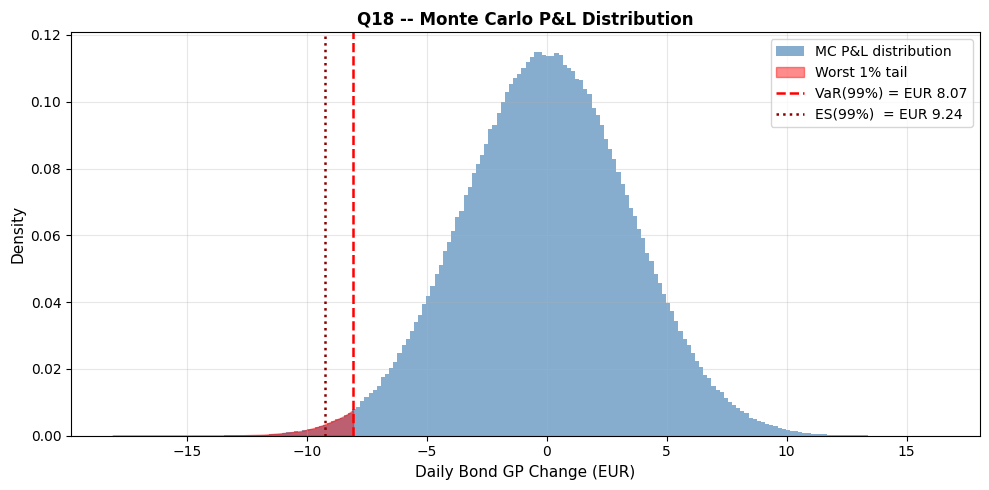

In [58]:
from scipy.stats import gaussian_kde
fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(sim_pnl, bins=200, density=True, alpha=0.65,
        color="steelblue", label="MC P&L distribution")
tail_pts = np.linspace(sim_pnl.min(), cutoff, 200)
kde = gaussian_kde(sim_pnl)
ax.fill_between(tail_pts, kde(tail_pts), alpha=0.45, color="red", label="Worst 1% tail")
ax.axvline(-VaR_MC, color="red",     linestyle="--", lw=1.8,
           label=f"VaR(99%) = EUR {VaR_MC:.2f}")
ax.axvline(-ES_MC,  color="darkred", linestyle=":",  lw=1.8,
           label=f"ES(99%)  = EUR {ES_MC:.2f}")
ax.set_xlabel("Daily Bond GP Change (EUR)", fontsize=11)
ax.set_ylabel("Density", fontsize=11)
ax.set_title("Q18 -- Monte Carlo P&L Distribution", fontsize=12, fontweight="bold")
ax.legend(fontsize=10); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()


---
## Q19: Exact analytical VaR and ES

In [59]:
var_by_factor = betas_all**2 * variances
var_total     = var_by_factor.sum()
sigma_total   = np.sqrt(var_total)

z_alpha   = norm.ppf(1 - ALPHA)
VaR_exact = sigma_total * z_alpha
ES_exact  = sigma_total * norm.pdf(z_alpha) / ALPHA

print("Q19 -- EXACT ANALYTICAL RESULTS")
print(f"  z_alpha (99%): {z_alpha:.4f}")
print(f"  sigma_GP:      {sigma_total:.4f} EUR")
print()
print("  Variance decomposition:")
print(f"  {'Factor':<22s}  {'Variance':>10s}  {'% of total':>11s}")
print("  " + "-"*46)
for name, v in zip(FACTOR_NAMES, var_by_factor):
    print(f"  {name:<22s}  {v:>10.4f}  {v/var_total*100:>10.1f}%")
print("  " + "-"*46)
print(f"  {'TOTAL':<22s}  {var_total:>10.4f}  {100:>10.1f}%")
print()
print(f"  VaR(99%) [Exact]: EUR {VaR_exact:.4f}")
print(f"  ES(99%)  [Exact]: EUR {ES_exact:.4f}")
print()
diff_var = VaR_MC - VaR_exact
diff_es  = ES_MC  - ES_exact
print(f"  MC vs Exact:  VaR diff = {diff_var:+.4f} ({diff_var/VaR_exact*100:+.2f}%),  "
      f"ES diff = {diff_es:+.4f} ({diff_es/ES_exact*100:+.2f}%)")


Q19 -- EXACT ANALYTICAL RESULTS
  z_alpha (99%): 2.3263
  sigma_GP:      3.4777 EUR

  Variance decomposition:
  Factor                    Variance   % of total
  ----------------------------------------------
  PC1 Level                   0.2671         2.2%
  PC2 Slope                   0.0283         0.2%
  PC3 Curvature               0.0065         0.1%
  CDS Spread                 11.7922        97.5%
  ----------------------------------------------
  TOTAL                      12.0941       100.0%

  VaR(99%) [Exact]: EUR 8.0902
  ES(99%)  [Exact]: EUR 9.2687

  MC vs Exact:  VaR diff = -0.0239 (-0.30%),  ES diff = -0.0239 (-0.26%)


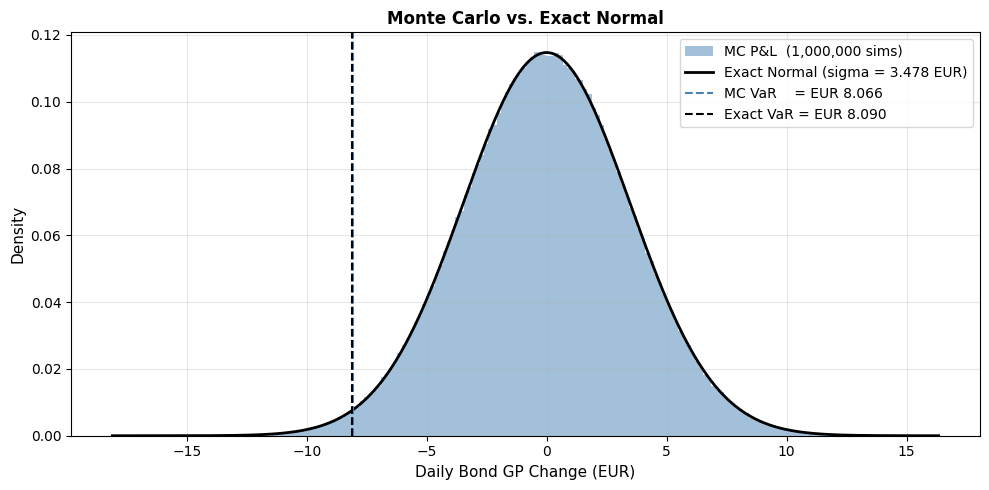


Limitations of the linear-normal approach:
  1. Linearity: ignores convexity and the cap/floor's changing delta.
  2. Normality: empirical changes have fat tails; normal model understates tail loss.
  3. Constant betas: sensitivities change as rates move and bond ages.
  4. Independence: in stress regimes IR factors and CDS spreads correlate.
  5. 1-day horizon: liquidity and compounding effects ignored.



In [70]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(sim_pnl, bins=200, density=True, alpha=0.5,
        color="steelblue", label=f"MC P&L  ({N_SIM:,} sims)")
x = np.linspace(sim_pnl.min(), sim_pnl.max(), 500)
ax.plot(x, norm.pdf(x, 0, sigma_total), color="black", lw=2,
        label=f"Exact Normal (sigma = {sigma_total:.3f} EUR)")
ax.axvline(-VaR_MC,    color="steelblue", linestyle="--", lw=1.5,
           label=f"MC VaR    = EUR {VaR_MC:.3f}")
ax.axvline(-VaR_exact, color="black",     linestyle="--", lw=1.5,
           label=f"Exact VaR = EUR {VaR_exact:.3f}")
ax.set_xlabel("Daily Bond GP Change (EUR)", fontsize=11)
ax.set_ylabel("Density", fontsize=11)
ax.set_title("Monte Carlo vs. Exact Normal", fontsize=12, fontweight="bold")
ax.legend(fontsize=10); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("figures/fig_q18_pnl_hist.pdf", bbox_inches="tight", dpi=150)
plt.show()

print("""
Limitations of the linear-normal approach:
  1. Linearity: ignores convexity and the cap/floor's changing delta.
  2. Normality: empirical changes have fat tails; normal model understates tail loss.
  3. Constant betas: sensitivities change as rates move and bond ages.
  4. Independence: in stress regimes IR factors and CDS spreads correlate.
  5. 1-day horizon: liquidity and compounding effects ignored.
""")


---
## Q20: Bond VaR decomposition (Euler formula)

In [61]:
marginal_var  = z_alpha * betas_all * variances / sigma_total
component_var = betas_all * marginal_var
pct_component = component_var / VaR_exact * 100

print("Q20 -- COMPONENT VaR DECOMPOSITION")
print()
print(f"  {'Factor':<22s}  {'Beta':>7s}  {'sigma':>9s}  {'MVaR':>9s}  {'CVaR':>9s}  {'% VaR':>7s}")
print("  " + "-"*72)
for i, name in enumerate(FACTOR_NAMES):
    print(f"  {name:<22s}  {betas_all[i]:>+7.3f}  "
          f"{np.sqrt(variances[i]):>9.4f}  "
          f"{marginal_var[i]:>+9.4f}  "
          f"{component_var[i]:>9.4f}  "
          f"{pct_component[i]:>6.2f}%")
print("  " + "-"*72)
print(f"  {'TOTAL':<22s}  {'':>7s}  {'':>9s}  {'':>9s}  "
      f"{component_var.sum():>9.4f}  {pct_component.sum():>6.2f}%")
print(f"  Cross-check: sum = {component_var.sum():.6f}  VaR = {VaR_exact:.6f}  "
      f"diff = {abs(component_var.sum()-VaR_exact):.2e}")


Q20 -- COMPONENT VaR DECOMPOSITION

  Factor                     Beta      sigma       MVaR       CVaR    % VaR
  ------------------------------------------------------------------------
  PC1 Level                +0.053     9.7324    +3.3645     0.1787    2.21%
  PC2 Slope                -0.052     3.2344    -0.3639     0.0189    0.23%
  PC3 Curvature            -0.061     1.3257    -0.0716     0.0044    0.05%
  CDS Spread               -0.735     4.6708   -10.7295     7.8883   97.50%
  ------------------------------------------------------------------------
  TOTAL                                                     8.0902  100.00%
  Cross-check: sum = 8.090235  VaR = 8.090235  diff = 3.55e-15


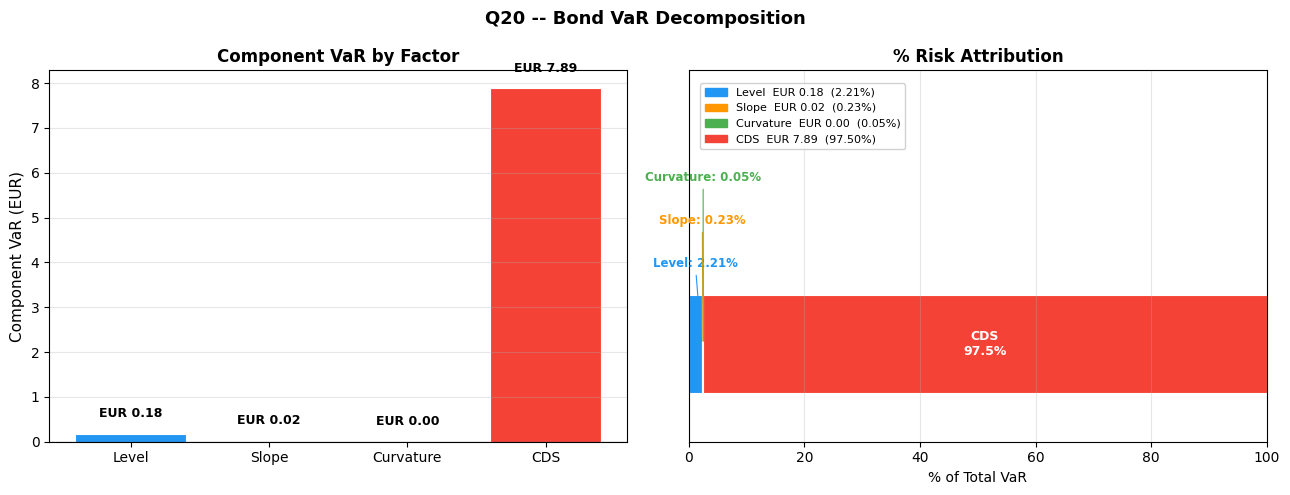

In [66]:
colors      = ["#2196F3", "#FF9800", "#4CAF50", "#F44336"]
short_names = ["Level", "Slope", "Curvature", "CDS"]
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# ── Left: component VaR bar chart ─────────────────────────────────
ax = axes[0]
bars = ax.bar(short_names, component_var, color=colors, edgecolor="white", lw=0.8)
ax.axhline(0, color="black", lw=0.8)
ax.set_ylabel("Component VaR (EUR)", fontsize=11)
ax.set_title("Component VaR by Factor", fontsize=12, fontweight="bold")
ax.grid(axis="y", alpha=0.3)
for bar, val in zip(bars, component_var):
    ypos = val + 0.3 if val >= 0 else val - 0.8
    ax.text(bar.get_x() + bar.get_width()/2, ypos, f"EUR {val:.2f}",
            ha="center", va="bottom" if val >= 0 else "top",
            fontsize=9, fontweight="bold")

# ── Right: horizontal stacked bar — % risk attribution ────────────────────────
ax2 = axes[1]
pct = np.abs(component_var) / np.abs(component_var).sum() * 100
left = 0.0
for i, (name, p, col) in enumerate(zip(short_names, pct, colors)):
    ax2.barh(0, p, left=left, color=col, edgecolor="white", lw=0.8, height=0.5)
    # Label inside if segment is wide enough; annotate outside otherwise
    x_center = left + p / 2
    if p >= 4.0:
        ax2.text(x_center, 0, f"{name}\n{p:.1f}%",
                 ha="center", va="center", fontsize=9,
                 fontweight="bold", color="white")
    else:
        # Narrow segments: stagger vertically so labels don't stack on one line
        y_offset = 0.38 + (i % 3) * 0.22
        ax2.annotate(
            f"{name}: {p:.2f}%",
            xy=(left + p, 0), xytext=(left + p / 2, y_offset),
            ha="center", va="bottom", fontsize=8.5, fontweight="bold",
            color=col,
            arrowprops=dict(arrowstyle="-", color=col, lw=0.8),
        )
    left += p

ax2.set_xlim(0, 100)
ax2.set_ylim(-0.5, 1.4)
ax2.set_xlabel("% of Total VaR", fontsize=10)
ax2.set_yticks([])
ax2.set_title("% Risk Attribution", fontsize=12, fontweight="bold")
ax2.grid(axis="x", alpha=0.3)

from matplotlib.patches import Patch
ax2.legend(
    handles=[Patch(color=c, label=f"{n}  EUR {v:.2f}  ({p:.2f}%)")
             for n, c, v, p in zip(short_names, colors, component_var, pct)],
    loc="upper left", bbox_to_anchor=(0.01, 0.98),
    fontsize=8, ncol=1, framealpha=0.9,
)

plt.suptitle("Q20 -- Bond VaR Decomposition", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()


---
## Q21: Portfolio VaR decomposition (bond + IRS 1Y/5Y/10Y hedges)

In [63]:
hedge_contrib_ir = hedge_beta_matrix.sum(axis=0)  # (3,)
betas_port = np.array([
    beta_bond[0] + hedge_contrib_ir[0],
    beta_bond[1] + hedge_contrib_ir[1],
    beta_bond[2] + hedge_contrib_ir[2],
    beta_cds,   # IRS has no CDS exposure
])

print("Portfolio betas (bond + IRS hedges):")
contrib_full = list(hedge_contrib_ir) + [0.0]
print(f"  {'Factor':<22s}  {'Bond':>10s}  {'Hedge':>10s}  {'Portfolio':>11s}")
print("  " + "-"*58)
for i, name in enumerate(FACTOR_NAMES):
    print(f"  {name:<22s}  {betas_all[i]:>+10.4f}  "
          f"{contrib_full[i]:>+10.4f}  {betas_port[i]:>+11.4e}")

var_port   = np.sum(betas_port**2 * variances)
sigma_port = np.sqrt(var_port)
VaR_port   = sigma_port * z_alpha
ES_port    = sigma_port * norm.pdf(z_alpha) / ALPHA
cvr_port   = z_alpha * betas_port**2 * variances / sigma_port
pct_cvr_port = cvr_port / VaR_port * 100 if VaR_port > 0 else np.zeros(4)
var_red_pct  = (VaR_exact - VaR_port) / VaR_exact * 100

print()
print("Q21 -- PORTFOLIO VaR DECOMPOSITION")
print()
print(f"  {'':22s}  {'Bond (unhedged)':>16s}  {'Portfolio (hedged)':>19s}")
print("  " + "-"*64)
print(f"  {'sigma_GP (EUR)':22s}  {sigma_total:>16.4f}  {sigma_port:>19.4f}")
print(f"  {'VaR(99%) (EUR)':22s}  {VaR_exact:>16.4f}  {VaR_port:>19.4f}  ({var_red_pct:.1f}% reduction)")
print(f"  {'ES(99%)  (EUR)':22s}  {ES_exact:>16.4f}  {ES_port:>19.4f}")
print()
print("  Component VaR:")
print(f"  {'Factor':<22s}  {'CVaR Bond':>10s}  {'CVaR Port':>10s}")
print("  " + "-"*46)
for i, name in enumerate(FACTOR_NAMES):
    print(f"  {name:<22s}  {component_var[i]:>10.4f}  {cvr_port[i]:>10.4f}")


Portfolio betas (bond + IRS hedges):
  Factor                        Bond       Hedge    Portfolio
  ----------------------------------------------------------
  PC1 Level                  +0.0531     -0.0531  +3.0480e-05
  PC2 Slope                  -0.0520     +0.0520  -3.7900e-06
  PC3 Curvature              -0.0609     +0.0609  -3.6210e-05
  CDS Spread                 -0.7352     +0.0000  -7.3520e-01

Q21 -- PORTFOLIO VaR DECOMPOSITION

                           Bond (unhedged)   Portfolio (hedged)
  ----------------------------------------------------------------
  sigma_GP (EUR)                    3.4777               3.4340
  VaR(99%) (EUR)                    8.0902               7.9886  (1.3% reduction)
  ES(99%)  (EUR)                    9.2687               9.1523

  Component VaR:
  Factor                   CVaR Bond   CVaR Port
  ----------------------------------------------
  PC1 Level                   0.1787      0.0000
  PC2 Slope                   0.0189      0.0000


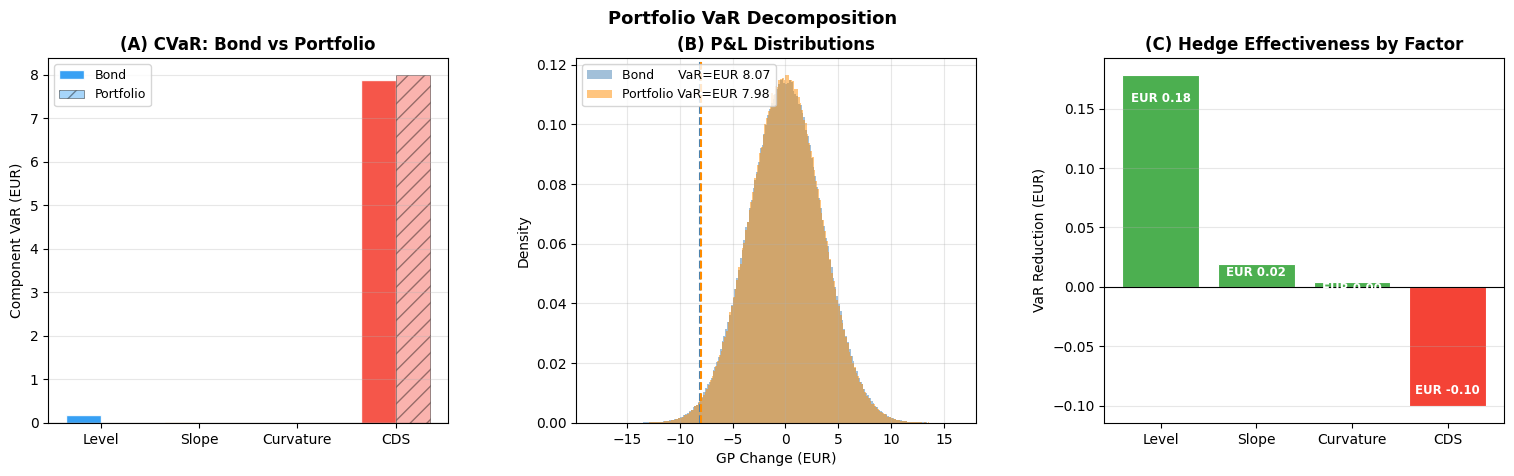

VaR reduction: 1.3%  (EUR 8.09 -> EUR 7.99)
Residual risk is almost entirely the unhedged CDS spread.


In [72]:
sim_pnl_port   = sim_factors @ betas_port
cutoff_port    = np.percentile(sim_pnl_port, ALPHA * 100)
VaR_port_MC    = -cutoff_port
ES_port_MC     = -sim_pnl_port[sim_pnl_port <= cutoff_port].mean()

fig, axes = plt.subplots(1, 3, figsize=(16, 4.8))
fig.subplots_adjust(top=0.88, bottom=0.12, left=0.06, right=0.97, wspace=0.32)

# ── (A) Component VaR: Bond vs Portfolio ──────────────────────────────────────
ax = axes[0]
x, bw = np.arange(4), 0.35
ax.bar(x-bw/2, component_var, width=bw, color=colors, alpha=0.9,
       edgecolor="white", label="Bond")
ax.bar(x+bw/2, cvr_port,      width=bw, color=colors, alpha=0.4,
       edgecolor="black", lw=0.7, hatch="//", label="Portfolio")
ax.axhline(0, color="black", lw=0.8)
ax.set_xticks(x); ax.set_xticklabels(short_names, fontsize=10)
ax.set_ylabel("Component VaR (EUR)")
ax.set_title("(A) CVaR: Bond vs Portfolio", fontweight="bold")
ax.legend(fontsize=9); ax.grid(axis="y", alpha=0.3)

# ── (B) P&L Distributions ─────────────────────────────────────────────────────
ax2 = axes[1]
ax2.hist(sim_pnl,      bins=200, density=True, alpha=0.5, color="steelblue",
         label=f"Bond      VaR=EUR {VaR_MC:.2f}")
ax2.hist(sim_pnl_port, bins=200, density=True, alpha=0.5, color="darkorange",
         label=f"Portfolio VaR=EUR {VaR_port_MC:.2f}")
ax2.axvline(-VaR_MC,      color="steelblue",  linestyle="--", lw=1.5)
ax2.axvline(-VaR_port_MC, color="darkorange", linestyle="--", lw=1.5)
ax2.set_xlabel("GP Change (EUR)"); ax2.set_ylabel("Density")
ax2.set_title("(B) P&L Distributions", fontweight="bold")
ax2.legend(fontsize=9); ax2.grid(alpha=0.3)

# ── (C) Hedge Effectiveness by Factor ─────────────────────────────────────────
ax3 = axes[2]
reductions  = component_var - cvr_port
bar_colors3 = ["#4CAF50" if r >= 0 else "#F44336" for r in reductions]
bars3 = ax3.bar(short_names, reductions, color=bar_colors3, edgecolor="white", lw=0.8)
ax3.axhline(0, color="black", lw=0.8)
ax3.set_ylabel("VaR Reduction (EUR)")
ax3.set_title("(C) Hedge Effectiveness by Factor", fontweight="bold")
ax3.grid(axis="y", alpha=0.3)

# Labels sit just inside the filled end of each bar; offset = 8% of bar height
for bar, r in zip(bars3, reductions):
    x_c    = bar.get_x() + bar.get_width() / 2
    offset = abs(bar.get_height()) * 0.08
    if r >= 0:
        ax3.text(x_c, r - offset, f"EUR {r:.2f}",
                 ha="center", va="top", fontsize=8.5, fontweight="bold", color="white")
    else:
        ax3.text(x_c, r + offset, f"EUR {r:.2f}",
                 ha="center", va="bottom", fontsize=8.5, fontweight="bold", color="white")

fig.suptitle("Portfolio VaR Decomposition", fontsize=13, fontweight="bold")
plt.savefig("figures/fig_q20q21_var_decomp.pdf", bbox_inches="tight", dpi=150)
plt.show()
print(f"VaR reduction: {var_red_pct:.1f}%  (EUR {VaR_exact:.2f} -> EUR {VaR_port:.2f})")
print("Residual risk is almost entirely the unhedged CDS spread.")

---
## Q22: Summary table

In [65]:
HEDGE_LABELS = ["IRS 1Y", "IRS 5Y", "IRS 10Y"]

print("=" * 105)
print("Q22 -- PORTFOLIO FAIR VALUES AND RISK SENSITIVITIES")
print("     Per EUR 1000 bond | Trade date: 5 November 2025")
print("=" * 105)
print()
print("A. FAIR VALUES")
print(f"  {'Instrument':<28s}  {'Gross Price (EUR)':>16s}  Note")
print("  " + "-"*70)
print(f"  {'UniCredit Bond 2034':<28s}  {bond_gross_price:>16.4f}  Risky gross price (Q15)")
for lbl in HEDGE_LABELS:
    print(f"  {lbl:<28s}  {'0.0000':>16s}  Zero at inception")
print()
print("B. FACTOR SENSITIVITIES  (EUR per 1 bp move in factor, per EUR 1000 nominal)")
print(f"  {'Instrument':<28s}  {'b_level':>9s}  {'b_slope':>9s}  {'b_curv':>9s}  {'b_cds':>9s}")
print("  " + "-"*72)
print(f"  {'UniCredit Bond 2034':<28s}  "
      f"{beta_bond[0]:>+9.4f}  {beta_bond[1]:>+9.4f}  {beta_bond[2]:>+9.4f}  {beta_cds:>+9.4f}")
for i, lbl in enumerate(HEDGE_LABELS):
    hb = hedge_beta_matrix[i]
    print(f"  {lbl:<28s}  {hb[0]:>+9.4f}  {hb[1]:>+9.4f}  {hb[2]:>+9.4f}  {'--':>9s}")
port_ir = beta_bond + hedge_beta_matrix.sum(axis=0)
print("  " + "-"*72)
print(f"  {'PORTFOLIO TOTAL':<28s}  "
      f"{port_ir[0]:>+9.2e}  {port_ir[1]:>+9.2e}  {port_ir[2]:>+9.2e}  {beta_cds:>+9.4f}")
print()
print("C. VAR / ES SUMMARY  (99%, 1-day, per EUR 1000 bond)")
print(f"  {'Metric':<35s}  {'Unhedged Bond':>14s}  {'Hedged Portfolio':>16s}")
print("  " + "-"*72)
rows = [
    ("VaR(99%) exact (EUR)",      VaR_exact, VaR_port),
    ("ES(99%)  exact (EUR)",       ES_exact,  ES_port),
    ("VaR(99%) MC    (EUR)",       VaR_MC,    VaR_port_MC),
    ("ES(99%)  MC    (EUR)",        ES_MC,    ES_port_MC),
    ("Total sigma_GP (EUR)",    sigma_total,  sigma_port),
    ("CVaR: Level IR (EUR)",  component_var[0], cvr_port[0]),
    ("CVaR: Slope IR (EUR)",  component_var[1], cvr_port[1]),
    ("CVaR: Curvature (EUR)", component_var[2], cvr_port[2]),
    ("CVaR: CDS Spread (EUR)",component_var[3], cvr_port[3]),
]
for lbl, bv, pv in rows:
    chg = (pv - bv) / bv * 100 if abs(bv) > 1e-10 else 0
    print(f"  {lbl:<35s}  {bv:>14.4f}  {pv:>16.4f}  ({chg:+.1f}%)")
print()
print(f"  VaR reduction from hedging: {var_red_pct:.1f}%.")
print("  CVaR components sum to total VaR (Euler decomposition).")
print("  Residual portfolio risk is the unhedged CDS spread.")
print()
print("=" * 105)


Q22 -- PORTFOLIO FAIR VALUES AND RISK SENSITIVITIES
     Per EUR 1000 bond | Trade date: 5 November 2025

A. FAIR VALUES
  Instrument                    Gross Price (EUR)  Note
  ----------------------------------------------------------------------
  UniCredit Bond 2034                  1072.9823  Risky gross price (Q15)
  IRS 1Y                                  0.0000  Zero at inception
  IRS 5Y                                  0.0000  Zero at inception
  IRS 10Y                                 0.0000  Zero at inception

B. FACTOR SENSITIVITIES  (EUR per 1 bp move in factor, per EUR 1000 nominal)
  Instrument                      b_level    b_slope     b_curv      b_cds
  ------------------------------------------------------------------------
  UniCredit Bond 2034             +0.0531    -0.0520    -0.0609    -0.7352
  IRS 1Y                          -0.0045    +0.0093    -0.0173         --
  IRS 5Y                          -0.0693    +0.0305    +0.0810         --
  IRS 10Y          